In [1]:
import os
import re
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Patch
from itertools import combinations
from scipy.stats import rankdata, norm
from statsmodels.stats.multitest import multipletests

sys.path.append("/mnt/lareaulab/reliscu/code")

from parse_gtf import *
from junction2psi import *

In [2]:
# data_source = "GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance_filtered_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance"

In [3]:
ctype_abund_df = pd.read_csv("data/ctype_abundance/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance_filtered_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance.csv", index_col=0)
psi = pd.read_csv(f"data/GTEx_cortex_exon_PSI.csv", index_col=0)
bulk_expr = pd.read_csv("GTEx_cortex_counts_TMMF_SampleNetworks/All_02-25-12/GTEx_cortex_counts_TMMF_All_501_outliers_removed.csv", index_col=0, )

In [4]:
intron_file = "/mnt/lareaulab/reliscu/data/GENCODE/GRCh38/psix_annotation/intron_file.tab.gz"
intron_table = read_intron_file(intron_file)

In [5]:
gtf_file = "/mnt/lareaulab/reliscu/data/GENCODE/GRCh38/gencode.v46.annotation.gtf"
gtf = gtf_parse(gtf_file)

In [6]:
column_order = [
    "CGE Class", "All GABAergic", "All Neuronal", "Upper layer glutamatergic", "Deep layer glutamatergic", 
    "Oligo", "OPC", "Astro", "Micro/PVM", "VLMC", "Endo", "Peri"
]

In [7]:
ctype_abund_df = ctype_abund_df[column_order]

## Get gene expression corrs

In [8]:
mean_expr = bulk_expr.mean(axis=1).rename('Expr').reset_index()
mean_expr.columns = ['Gene', 'Expr']

In [9]:
keep = mean_expr.groupby('Gene')['Expr'].idxmax()
bulk_expr_filtered = bulk_expr.iloc[keep] 

In [10]:
# Filter 0 genes

mask = bulk_expr_filtered.iloc[:, 1:].mean(axis=1) > 0
bulk_expr_filtered = bulk_expr_filtered[mask]

In [11]:
bulk_expr.shape

(56997, 501)

In [12]:
bulk_expr_filtered.shape

(55403, 501)

In [13]:
# Make sure sampel order matches:

bulk_expr_filtered = bulk_expr_filtered[ctype_abund_df.index]

In [14]:
np.all(bulk_expr_filtered.columns == ctype_abund_df.index)

True

In [15]:
# Correlate each cell type with each gene

expr_array = bulk_expr_filtered.values

expr_rank_matrix = np.apply_along_axis(
    lambda x: rankdata(np.where(np.isnan(x), np.nan, x), method='average'),
    axis=1,
    arr=expr_array
)  # (n_genes, n_samples)

# center PSI ranks once
expr_rank_centered = expr_rank_matrix - np.nanmean(expr_rank_matrix, axis=1, keepdims=True)
expr_rank_norm = np.sqrt(np.nansum(expr_rank_centered ** 2, axis=1, keepdims=True))  # (n_genes, 1)

expr_corr_results = {}
for ct in ctype_abund_df.columns:
    ct_vals = ctype_abund_df[ct].values        # (n_samples,)
    ct_ranks = rankdata(ct_vals, method='average')  # (n_samples,)
    
    # --- observed correlation ---
    ct_centered = ct_ranks - ct_ranks.mean()
    ct_norm = np.sqrt((ct_centered ** 2).sum())
    observed = (expr_rank_centered @ ct_centered) / (expr_rank_norm.squeeze() * ct_norm) # shape: (n_genes,)
    expr_corr_results[ct] = observed
    
expr_corr_df = pd.DataFrame(expr_corr_results)

In [16]:
expr_corr_df.set_index(bulk_expr_filtered.index, inplace=True)

In [17]:
expr_corr_df.sort_values("Astro", ascending=False).head(10)

,CGE Class,All GABAergic,All Neuronal,Upper layer glutamatergic,Deep layer glutamatergic,Oligo,OPC,Astro,Micro/PVM,VLMC,Endo,Peri
datExprT...c.1.skip1..,,,,,,,,,,,,
STOX1,0.020194,-0.038870,-0.236353,-0.215807,-0.331584,0.169210,0.745047,0.974466,0.190218,0.453441,0.492365,0.537296
ALDH6A1,-0.034537,-0.104042,-0.252123,-0.223808,-0.330298,0.208170,0.699657,0.972790,0.195334,0.465951,0.540196,0.534068
PPARA,-0.025207,-0.081034,-0.272819,-0.261700,-0.298673,0.243326,0.758127,0.970629,0.211498,0.505700,0.558423,0.587160
RAB31,-0.028702,-0.064554,-0.270651,-0.266130,-0.293457,0.220881,0.810040,0.970206,0.252517,0.496970,0.523691,0.563156
HSDL2,-0.026914,-0.058747,-0.237958,-0.260346,-0.257089,0.241226,0.757752,0.951076,0.268998,0.456393,0.521528,0.509498
PON2,-0.077868,-0.123361,-0.302625,-0.319164,-0.276387,0.279642,0.770466,0.950538,0.226073,0.496810,0.566072,0.570473
KAT2B,-0.066715,-0.097146,-0.251015,-0.273778,-0.215355,0.359085,0.805706,0.945605,0.248015,0.517994,0.572894,0.588808
GPR137B,0.035928,-0.005425,-0.198664,-0.208954,-0.290348,0.243355,0.775104,0.944113,0.240144,0.480794,0.513738,0.547585
MSI2,0.009658,-0.044588,-0.232417,-0.242329,-0.303326,0.204722,0.756543,0.942907,0.253922,0.481727,0.543258,0.547541


## Parse GTF (to annotate exons with their genes)

In [18]:
# Parse GTF attribute column

gtf_subset = gtf.loc[gtf['feature'].isin(["gene"])]
attrs = gtf_subset["attribute"].apply(extract_attributes)
attrs_df = attrs.apply(pd.Series)
gtf_parsed = pd.concat([gtf_subset.drop(columns=["attribute"]), attrs_df], axis=1)
gtf_parsed['gene_id'] = gtf_parsed['gene_id'].str.split(".").str[0]

## Format PSI data

In [20]:
np.all(psi.columns == ctype_abund_df.index)

True

In [21]:
# Get PSI data ready to merge on gene IDs
psi['gene_id'] = psi.index.str.split("_").str[0]
psi['exon_id'] = psi.index.values

psi_anno = pd.merge(gtf_parsed[['gene_id', 'gene_name']], psi, on="gene_id", how="right")
psi_anno = psi_anno.set_index("exon_id").rename_axis(None)
psi_anno = psi_anno.drop(columns=["gene_id"])

## Get exon coords

In [22]:
# Get coordinates for each exon
intron_coords_df = intron_table['intron'].str.split(r"[:\-]", expand=True).iloc[:, :3]
intron_coords_df.columns = ["chr", "intron_first_base", "intron_last_base"]
intron_coords_df.index = intron_table.index
intron_coords_df['exon'] = intron_coords_df.index.str.split("_").str[:3].str.join("_")
intron_coords_df = intron_coords_df[intron_coords_df['exon'].isin(psi_anno.index)] # Subset to exons in PSI data
intron_coords_df['intron_first_base'] = intron_coords_df["intron_first_base"].astype(int)
intron_coords_df['intron_last_base'] = intron_coords_df["intron_last_base"].astype(int)

def safe_exon_coords(g):
    i1 = g.loc[g.index.str.contains("I1$"), "intron_last_base"].values
    i2 = g.loc[g.index.str.contains("I2$"), "intron_first_base"].values
    if len(i1) == 0 or len(i2) == 0:
        return pd.Series({"chr": None, "exon_start": None, "exon_end": None})
    return pd.Series({
        "chr": g["chr"].iloc[0],
        "exon_start": i1[0] + 1,
        "exon_end": i2[0] - 1,
    })


exon_coords_df = intron_coords_df.groupby("exon").apply(safe_exon_coords)
exon_coords_df = exon_coords_df.dropna()  # drop exons with missing coords

/tmp/ipykernel_1139918/3914303081.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  exon_coords_df = intron_coords_df.groupby("exon").apply(safe_exon_coords)


In [23]:
exon_coords_df.head()

,chr,exon_start,exon_end
exon,,,
ENSG00000000003_ProteinCoding_1,chrX,100632485,100632568
ENSG00000000419_NMD_1,chr20,50940865,50940955
ENSG00000000419_ProteinCoding_1,chr20,50940865,50940933
ENSG00000000419_ProteinCoding_2,chr20,50941105,50941209
ENSG00000000419_ProteinCoding_3,chr20,50941129,50941209


## Calc PSI corrs and plot

### Functions

In [24]:
# =============================================================================
# 1. SPEARMAN CORRELATION + PERMUTATION P-VALUES + FDR + ANALYTICAL CIs
# =============================================================================

def analytical_ci(r, n, ci=0.95):
    """
    Fisher Z-transform based confidence intervals for correlation.
    Exact for Pearson, approximate for Spearman.

    Parameters
    ----------
    r   : array-like, observed correlations
    n   : int, number of samples
    ci  : float, confidence level (default 0.95)

    Returns
    -------
    lower, upper : arrays of CI bounds
    """
    r = np.asarray(r)
    r_clipped = np.clip(r, -0.9999, 0.9999)
    z = np.arctanh(r_clipped)
    se = 1 / np.sqrt(n - 3)
    z_crit = norm.ppf((1 + ci) / 2)
    lower = np.tanh(z - z_crit * se)
    upper = np.tanh(z + z_crit * se)
    return lower, upper


def bootstrap_ci(psi_rank_centered, ct_ranks, n_boot=1000, ci=95, seed=42):
    """
    Bootstrap confidence intervals for Spearman correlation.
    Only call this for specific exons you intend to plot — slow for all exons.

    Parameters
    ----------
    psi_rank_centered : np.array, shape (n_exons, n_samples)
    ct_ranks          : np.array, shape (n_samples,)
    n_boot            : int, number of bootstrap iterations
    ci                : float, confidence level (default 95)
    seed              : int, random seed

    Returns
    -------
    lower, upper : arrays of CI bounds, shape (n_exons,)
    """
    np.random.seed(seed)
    n_samples = psi_rank_centered.shape[1]

    boot_indices = np.random.choice(n_samples, size=(n_boot, n_samples), replace=True)

    ct_boot_all = ct_ranks[boot_indices]                                        # (n_boot, n_samples)
    ct_boot_centered = ct_boot_all - ct_boot_all.mean(axis=1, keepdims=True)   # (n_boot, n_samples)
    ct_boot_norm = np.sqrt((ct_boot_centered**2).sum(axis=1))                  # (n_boot,)

    boot_corrs = np.zeros((n_boot, psi_rank_centered.shape[0]))
    for i in range(n_boot):
        idx = boot_indices[i]
        psi_boot = psi_rank_centered[:, idx]
        psi_boot_norm = np.sqrt(np.nansum(psi_boot**2, axis=1, keepdims=True))
        boot_corrs[i, :] = (psi_boot @ ct_boot_centered[i]) / (psi_boot_norm.squeeze() * ct_boot_norm[i])

    lower = np.percentile(boot_corrs, (100 - ci) / 2, axis=0)
    upper = np.percentile(boot_corrs, 100 - (100 - ci) / 2, axis=0)
    return lower, upper


def spearman_permutation_test(psi_numeric, ctype_abund_df, psi_anno,
                               n_perms=1000, ci=0.95, seed=42):
    """
    Compute Spearman correlations between each PSI event and each cell type,
    with permutation-based p-values, BH-FDR correction, and analytical CIs.
    Also returns permuted correlations for use in permutation-based
    correlation difference test.
 
    Parameters
    ----------
    psi_numeric     : pd.DataFrame, shape (n_exons, n_samples)
    ctype_abund_df  : pd.DataFrame, shape (n_samples, n_celltypes)
    psi_anno        : pd.DataFrame with 'gene_name' column
    n_perms         : int, number of permutations
    ci              : float, confidence level for analytical CIs
    seed            : int, random seed
 
    Returns
    -------
    psi_corr_df       : Spearman r values
    psi_pval_df       : permutation p-values
    psi_fdr_df        : BH-FDR corrected p-values (within each cell type)
    psi_ci_lower_df   : analytical CI lower bounds
    psi_ci_upper_df   : analytical CI upper bounds
    perm_corr_results : dict {ct: (n_exons, n_perms) array} of permuted correlations
    psi_rank_centered : (n_exons, n_samples) centered rank matrix (for bootstrap CIs)
    psi_rank_norm     : (n_exons, 1) rank norms (for bootstrap CIs)
    ct_ranks_dict     : dict {ct: (n_samples,) array} of ranked ct values (for bootstrap CIs)
    """
    np.random.seed(seed)
 
    n_samples = psi_numeric.shape[1]
 
    # --- precompute PSI ranks once ---
    psi_array = psi_numeric.values  # (n_exons, n_samples)
    psi_rank_matrix = np.apply_along_axis(
        lambda x: rankdata(np.where(np.isnan(x), np.nan, x), method='average'),
        axis=1,
        arr=psi_array
    )  # (n_exons, n_samples)
 
    # center PSI ranks once
    psi_rank_centered = psi_rank_matrix - np.nanmean(psi_rank_matrix, axis=1, keepdims=True)
    psi_rank_norm = np.sqrt(np.nansum(psi_rank_centered ** 2, axis=1, keepdims=True))  # (n_exons, 1)
 
    # --- precompute all permutation indices ---
    perm_indices = np.array([np.random.permutation(n_samples) for _ in range(n_perms)])
    # shape: (n_perms, n_samples)
 
    corr_results = {}
    pval_results = {}
    perm_corr_results = {}
    ct_ranks_dict = {}
 
    for ct in ctype_abund_df.columns:
        ct_vals = ctype_abund_df[ct].values
        ct_ranks = rankdata(ct_vals, method='average')
        ct_ranks_dict[ct] = ct_ranks
 
        # --- observed correlation ---
        ct_centered = ct_ranks - ct_ranks.mean()
        ct_norm = np.sqrt((ct_centered ** 2).sum())
        observed = (psi_rank_centered @ ct_centered) / (psi_rank_norm.squeeze() * ct_norm)
        # shape: (n_exons,)
 
        # --- all permutations at once ---
        ct_perm_ranks = ct_ranks[perm_indices]          # (n_perms, n_samples)
        ct_perm_centered = ct_perm_ranks - ct_perm_ranks.mean(axis=1, keepdims=True)
        ct_perm_norm = np.sqrt((ct_perm_centered ** 2).sum(axis=1))  # (n_perms,)
 
        # (n_exons, n_samples) @ (n_samples, n_perms) = (n_exons, n_perms)
        num = psi_rank_centered @ ct_perm_centered.T
        denom = psi_rank_norm * ct_perm_norm[np.newaxis, :]  # (n_exons, n_perms)
        perm_corrs = num / denom                             # (n_exons, n_perms)
 
        # --- two-tailed permutation p-values ---
        pvals = (np.abs(perm_corrs) >= np.abs(observed[:, np.newaxis])).mean(axis=1)
 
        corr_results[ct] = observed
        pval_results[ct] = pvals
        perm_corr_results[ct] = perm_corrs  # store for correlation difference test
 
        print(f"Done: {ct}")
 
    # --- assemble output dataframes ---
    psi_corr_df = pd.DataFrame(corr_results, index=psi_numeric.index)
    psi_corr_df.insert(0, 'Gene', psi_anno['gene_name'])
 
    psi_pval_df = pd.DataFrame(pval_results, index=psi_numeric.index)
    psi_pval_df.insert(0, 'Gene', psi_anno['gene_name'])
 
    # --- BH-FDR correction within each cell type ---
    psi_fdr_df = psi_pval_df.copy()
    for ct in ctype_abund_df.columns:
        pvals = psi_pval_df[ct].values
        mask = ~np.isnan(pvals)
        fdr = np.full(len(pvals), np.nan)
        _, fdr[mask], _, _ = multipletests(pvals[mask], method='fdr_bh')
        psi_fdr_df[ct] = fdr
 
    # --- analytical CIs ---
    n = psi_numeric.shape[1]
    psi_ci_lower_df = psi_corr_df.copy()
    psi_ci_upper_df = psi_corr_df.copy()
    for ct in ctype_abund_df.columns:
        lower, upper = analytical_ci(psi_corr_df[ct].values, n, ci=ci)
        psi_ci_lower_df[ct] = lower
        psi_ci_upper_df[ct] = upper
 
    return (psi_corr_df, psi_pval_df, psi_fdr_df, psi_ci_lower_df, psi_ci_upper_df,
            perm_corr_results, psi_rank_centered, psi_rank_norm, ct_ranks_dict)


# =============================================================================
# 2. PERMUTATION-BASED CORRELATION DIFFERENCE TEST
# =============================================================================

def compare_all_ct_pairs(psi_corr_df, perm_corr_results, psi_anno, ct_cols):
    """
    Permutation-based test for difference between dependent correlations.
    Reuses permuted correlations from spearman_permutation_test — no extra
    computation needed.

    For each pair (ct1, ct2), the null distribution of r(PSI, ct1) - r(PSI, ct2)
    is computed from the permuted correlations. This avoids the analytical
    Steiger formula and its det_R <= 0 edge cases.

    Parameters
    ----------
    psi_corr_df       : pd.DataFrame, observed correlations (no Gene column)
    perm_corr_results : dict {ct: (n_exons, n_perms) array}
    psi_anno          : pd.DataFrame with 'gene_name' column
    ct_cols           : list of cell type column names

    Returns
    -------
    dict keyed by (ct1, ct2) tuples, values are DataFrames with columns:
        Gene, r_ct1, r_ct2, r_diff, pval, fdr
    where r_diff = r(PSI, ct1) - r(PSI, ct2), positive means ct1 > ct2
    """
    all_pvals = []
    all_keys = []
    all_masks = []
    results = {}

    for ct1, ct2 in combinations(ct_cols, 2):
        observed_ct1 = psi_corr_df[ct1].values   # (n_exons,)
        observed_ct2 = psi_corr_df[ct2].values   # (n_exons,)

        perm_ct1 = perm_corr_results[ct1]         # (n_exons, n_perms)
        perm_ct2 = perm_corr_results[ct2]         # (n_exons, n_perms)

        observed_diff = observed_ct1 - observed_ct2           # (n_exons,)
        perm_diff = perm_ct1 - perm_ct2                       # (n_exons, n_perms)

      # one-tailed p-value in the observed direction
        pvals = np.where(
            observed_diff >= 0,
            (perm_diff >= observed_diff[:, np.newaxis]).mean(axis=1),  # p(ct1 > ct2)
            (perm_diff <= observed_diff[:, np.newaxis]).mean(axis=1)   # p(ct1 < ct2)
        )

        mask = ~np.isnan(pvals)
        results[(ct1, ct2)] = {
            'observed_diff': observed_diff,
            'pvals': pvals, 
            'r_ct1': observed_ct1,
            'r_ct2': observed_ct2
        }
        #             'mask': mask,
        
        # collect valid (non-NaN) pvals for FDR correction
        # we concatenate across all pairs so FDR is corrected globally
        all_pvals.append(pvals[mask])
        all_keys.append((ct1, ct2))
        all_masks.append(mask)

     # --- FDR correct all pairs together, one correction per direction ---
    all_pvals_concat = np.concatenate(all_pvals)
    _, all_fdr_concat, _, _ = multipletests(all_pvals_concat, method='fdr_bh')

    # split FDR back into per-pair results
    idx = 0
    final_results = {}
    for (ct1, ct2), mask in zip(all_keys, all_masks):
        n_valid = mask.sum()

        fdr = np.full(len(mask), np.nan)
        fdr[mask] = all_fdr_concat[idx:idx + n_valid]
        idx += n_valid

        d = results[(ct1, ct2)]
        final_results[(ct1, ct2)] = pd.DataFrame({
            'Gene': psi_anno['gene_name'].values,
            f'r_{ct1}': d['r_ct1'],
            f'r_{ct2}': d['r_ct2'],
            'r_diff': d['observed_diff'],       # positive = ct1 > ct2
            'pval': d['pvals'],  
            'fdr': fdr       
        }, index=psi_corr_df.index)

    return final_results

# =============================================================================
# 3. FIND CELL-TYPE-SPECIFIC EXONS
# =============================================================================

def find_specific_exons_per_ct_basic(psi_fdr_df, psi_corr_df, fdr_thresh=0.05):
    """
    For each cell type, find exons where FDR < fdr_thresh.

    Returns
    -------
    dict of {ct: DataFrame}
    """
    ct_cols = [c for c in psi_fdr_df.columns if c != 'Gene']
    results = {}
    for target_ct in ct_cols:
        mask = psi_fdr_df[target_ct] < fdr_thresh
        n_total = mask.sum()
        print(f"{target_ct}: {n_total} significant exons")
        results[target_ct] = psi_corr_df[mask].sort_values(target_ct, ascending=False)
    return results


def find_specific_exons_per_ct(steiger_results, psi_fdr_df, psi_corr_df, ct_hierarchy, fdr_thresh=0.05, ascending=False):
    """
    For each cell type, find exons where:
    1. FDR < fdr_thresh for that cell type
    2. Correlation difference is significantly greater (or lesser if ascending)
       than all non-child cell types by permutation-based test (r_diff direction + FDR < fdr_thresh). Children defined in ct_hierarchy are excluded.

    Parameters
    ----------
    steiger_results : dict from compare_all_ct_pairs
    psi_fdr_df      : FDR DataFrame (no Gene column)
    psi_corr_df     : correlation DataFrame (with Gene column)
    ct_hierarchy    : dict {ct: [children to skip]}
    fdr_thresh      : float
    ascending       : bool, if True find exons where target has LOWEST correlation

    Returns
    -------
    dict of {ct: DataFrame}
    """
    ct_cols = [c for c in psi_fdr_df.columns if c != 'Gene']
    results = {}

    for target_ct in ct_cols:
        children_to_skip = ct_hierarchy.get(target_ct, [])
        other_cts = [ct for ct in ct_cols if ct != target_ct and ct not in children_to_skip]

        # condition 1: significant in target cell type
        sig_mask = psi_fdr_df[target_ct] < fdr_thresh

        # condition 2: significantly greater (or lesser) than all non-child cell types
        greater_mask = pd.Series(True, index=psi_fdr_df.index)

        for other_ct in other_cts:
            
            if (target_ct, other_ct) in steiger_results:
                df = steiger_results[(target_ct, other_ct)]
                if ascending:
                    ct_greater = (df['r_diff'] < 0) & (df['fdr'] < fdr_thresh)
                else:
                    ct_greater = (df['r_diff'] > 0) & (df['fdr'] < fdr_thresh)
            elif (other_ct, target_ct) in steiger_results:
                df = steiger_results[(other_ct, target_ct)]
                if ascending:
                    ct_greater = (df['r_diff'] > 0) & (df['fdr'] < fdr_thresh)
                else:
                    ct_greater = (df['r_diff'] < 0) & (df['fdr'] < fdr_thresh)
            else:
                print(f"Warning: no result found for ({target_ct}, {other_ct})")
                ct_greater = pd.Series(False, index=psi_fdr_df.index)

            greater_mask = greater_mask & ct_greater

        mask = sig_mask & greater_mask
        n_total = sig_mask.sum()
        n_specific = mask.sum()
        print(f"{target_ct}: {n_specific} specific exons ({n_total} significant total)")

        results[target_ct] = psi_corr_df[mask].sort_values(target_ct, ascending=ascending)

    return results


# =============================================================================
# 4. COMBINE RESULTS
# =============================================================================

def combine_results(ctype_specific_exons_basic, ctype_specific_exons_strict,
                    psi_corr_df, psi_fdr_df, steiger_results, ct_hierarchy, exon_coords_df):
    """
    For each cell type, combine basic (FDR only) and strict (FDR + permutation
    difference test) results into a single table.

    Steiger columns (r_diff, fdr) are filled only for specific exons,
    NaN for non-specific exons.

    Returns
    -------
    dict of {ct: DataFrame}
    """
    ct_cols = [c for c in psi_corr_df.columns if c != 'Gene']
    combined = {}

    for target_ct in ct_cols:
        # start from all FDR-significant exons
        all_sig = ctype_specific_exons_basic.get(target_ct, pd.DataFrame()).copy()
        if len(all_sig) == 0:
            continue

        # mark which exons passed strict criterion in either direction
        strict_true = set(ctype_specific_exons_strict['True'].get(target_ct, pd.DataFrame()).index)
        strict_false = set(ctype_specific_exons_strict['False'].get(target_ct, pd.DataFrame()).index)
        all_sig['is_specific'] = all_sig.index.isin(strict_true | strict_false)
        all_sig['specific_direction'] = np.where(
            all_sig.index.isin(strict_false), 'highest',
            np.where(all_sig.index.isin(strict_true), 'lowest', np.nan)
        )

        # add r and fdr for target cell type
        all_sig['r'] = psi_corr_df.loc[all_sig.index, target_ct]
        all_sig['fdr'] = psi_fdr_df.loc[all_sig.index, target_ct]
        all_sig['exon_start'] = exon_coords_df.loc[all_sig.index, 'exon_start']
        all_sig['exon_end'] = exon_coords_df.loc[all_sig.index, 'exon_end']
        all_sig['exon_len'] = all_sig['exon_end'] - all_sig['exon_start'] + 1
        all_sig['chr'] = exon_coords_df.loc[all_sig.index, 'chr']

        # add r_diff and fdr for non-child cell types — only for specific exons
        children_to_skip = ct_hierarchy.get(target_ct, [])
        other_cts = [ct for ct in ct_cols if ct != target_ct and ct not in children_to_skip]

        specific_idx = all_sig[all_sig['is_specific']].index

        for other_ct in other_cts:
            # initialize all as NaN
            all_sig[f'r_diff_{other_ct}'] = np.nan
            all_sig[f'fdr_diff_{other_ct}'] = np.nan  # renamed

            if len(specific_idx) == 0:
                continue

            if (target_ct, other_ct) in steiger_results:
                sdf = steiger_results[(target_ct, other_ct)]
                r_diff_vals = sdf.loc[specific_idx, 'r_diff'].values
                fdr_vals = sdf.loc[specific_idx, 'fdr'].values
            elif (other_ct, target_ct) in steiger_results:
                sdf = steiger_results[(other_ct, target_ct)]
                r_diff_vals = sdf.loc[specific_idx, 'r_diff'].values * -1  # flip sign
                fdr_vals = sdf.loc[specific_idx, 'fdr'].values             # fdr stays the same
            else:
                continue

            all_sig.loc[specific_idx, f'r_diff_{other_ct}'] = r_diff_vals
            all_sig.loc[specific_idx, f'fdr_diff_{other_ct}'] = fdr_vals

        combined[target_ct] = all_sig.sort_values('r', ascending=False)

    return combined

# =============================================================================
# 5. PLOTTING
# =============================================================================

def _safe(name):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(name))

def plot_ctype_exons(
    ctype_specific_exons,
    psi_corr_df,
    psi_fdr_df,
    expr_corr_df,
    exon_coords_df,
    psi_rank_centered,
    ct_ranks_dict,
    outdir,
    psi_ci_lower_df=None,   # required if use_bootstrap_ci=False
    psi_ci_upper_df=None,   # required if use_bootstrap_ci=False
    fdr_thresh=0.05,
    ascending=False,
    n_boot=1000,
    use_bootstrap_ci=True
):
    ct_cols = [c for c in psi_corr_df.columns if c != 'Gene']
    os.makedirs(outdir, exist_ok=True)
    psi_rank_np = np.array(psi_rank_centered, dtype=float)  # convert once

    for target_ct, exon_df in ctype_specific_exons.items():
        if len(exon_df) == 0:
            print(f"Skipping {target_ct} — no specific exons")
            continue

        pdf_path = f"{outdir}/{_safe(target_ct)}_specific_exons_ascending{ascending}_bootstrapCIs{use_bootstrap_ci}.pdf"
        print(f"Plotting {len(exon_df)} exons for {target_ct} -> {pdf_path}")

        with PdfPages(pdf_path) as pdf:
            for idx, row in exon_df.iterrows():
                gene = row['Gene']
                exon = "_".join(idx.split("_")[1:])

                exon_pos = int(psi_corr_df.index.get_loc(idx))
                r_vals   = psi_corr_df.loc[idx, ct_cols].values.astype(float)
                fdr_vals = psi_fdr_df.loc[idx, ct_cols].values.astype(float)

                # --- CIs ---
                if use_bootstrap_ci:
                    exon_rank_centered = psi_rank_np[exon_pos:exon_pos+1, :]
                    lowers, uppers = [], []
                    for ct in ct_cols:
                        ct_ranks = np.array(ct_ranks_dict[ct])
                        lo, hi = bootstrap_ci(
                            exon_rank_centered,
                            ct_ranks,
                            n_boot=n_boot,
                            ci=95,
                            seed=42
                        )
                        lowers.append(lo[0])
                        uppers.append(hi[0])
                    lower = np.array(lowers)
                    upper = np.array(uppers)
                else:
                    if psi_ci_lower_df is None or psi_ci_upper_df is None:
                        raise ValueError("psi_ci_lower_df and psi_ci_upper_df required when use_bootstrap_ci=False")
                    lower = psi_ci_lower_df.loc[idx, ct_cols].values.astype(float)
                    upper = psi_ci_upper_df.loc[idx, ct_cols].values.astype(float)

                # expression correlation
                try:
                    r_corr_vals = expr_corr_df.loc[gene].values.astype(float)
                except KeyError:
                    r_corr_vals = np.zeros(len(ct_cols))

                # exon coordinates
                start_coord = int(exon_coords_df.loc[idx]['exon_start'])
                end_coord   = int(exon_coords_df.loc[idx]['exon_end'])
                exon_len    = end_coord - start_coord + 1

                fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), dpi=200)
                fig.suptitle(f'{target_ct}', fontsize=16)

                colors = ['salmon' if c == target_ct else 'steelblue' for c in ct_cols]
                x = np.arange(len(ct_cols))

                # --- left panel: PSI correlations ---
                yerr = np.array([
                    np.maximum(r_vals - lower, 0),
                    np.maximum(upper - r_vals, 0)
                ])
                axes[0].bar(x, r_vals, color=colors, yerr=yerr, capsize=4,
                            error_kw=dict(elinewidth=1, ecolor='black'))

                for i, fdr in enumerate(fdr_vals):
                    if fdr < fdr_thresh:
                        if r_vals[i] >= 0:
                            y_pos = upper[i] + 0.02
                            va = 'bottom'
                        else:
                            y_pos = lower[i] - 0.02
                            va = 'top'
                        axes[0].text(i, y_pos, '*', ha='center', va=va,
                                     fontsize=12, color='black')

                target_idx = ct_cols.index(target_ct)
                axes[0].set_title(
                    f'{gene} {exon} exon (Spearman r = {np.round(r_vals[target_idx], 2)})\n'
                    f'{exon_len} nts ({start_coord}-{end_coord})'
                )
                axes[0].set_ylabel('Spearman r')
                axes[0].axhline(0, color='black', linewidth=0.6)
                axes[0].set_xticks(x)
                axes[0].set_xticklabels(ct_cols, rotation=45, ha='right', fontsize=9)
                axes[0].set_ylim(
                    min(-0.1, np.nanmin(lower) - 0.05),
                    max(0.1, np.nanmax(upper) + 0.1)
                )

                # --- right panel: gene expression correlations ---
                axes[1].set_title(f'{gene} gene expression')
                axes[1].bar(x, r_corr_vals, color=colors)
                axes[1].set_ylabel('Spearman r')
                axes[1].axhline(0, color='black', linewidth=0.6)
                axes[1].set_xticks(x)
                axes[1].set_xticklabels(ct_cols, rotation=45, ha='right', fontsize=9)

                plt.tight_layout()
                pdf.savefig(fig)
                plt.close(fig)

### Run

In [25]:
# CELL TYPE HIERARCHY

ct_hierarchy = {
    # broader cell types skip their subtypes (subtypes listed as children)
    'All Neuronal':              ['All GABAergic', 'CGE Class',
                                  'Upper layer glutamatergic',
                                  'Deep layer glutamatergic'],
    'All GABAergic':             ['CGE Class'],
    # specific subtypes must be greater than everything
    'CGE Class':                 [],
    'Upper layer glutamatergic': [],
    'Deep layer glutamatergic':  [],
    # non-neuronal
    'Oligo':                     [],
    'OPC':                       [],
    'Astro':                     [],
    'Micro/PVM':                 [],
    'VLMC':                      [],
    'Endo':                      [],
    'Peri':                      [],
}

psi_numeric = psi_anno.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

# --- correlations + permutation p-values + FDR + CIs ---
(psi_corr_df, psi_pval_df, psi_fdr_df, psi_ci_lower_df, psi_ci_upper_df,
 perm_corr_results, psi_rank_centered, psi_rank_norm, ct_ranks_dict) = spearman_permutation_test(
    psi_numeric,
    ctype_abund_df,
    psi_anno,
    n_perms=10000,
    ci=0.95
)
print("")

# --- permutation-based correlation difference test ---
steiger_results = compare_all_ct_pairs(
    psi_corr_df.drop(columns='Gene'),
    perm_corr_results,
    psi_anno,
    ctype_abund_df.columns.tolist()
)

# --- find specific exons ---
ctype_specific_exons_basic = find_specific_exons_per_ct_basic(
    psi_fdr_df.drop(columns='Gene'),
    psi_corr_df,
    fdr_thresh=0.05
)
print("")

ctype_specific_exons_strict = {}
for ascending in (True, False):
    ctype_specific_exons_strict[str(ascending)] = find_specific_exons_per_ct(
        steiger_results,
        psi_fdr_df.drop(columns='Gene'),
        psi_corr_df,
        ct_hierarchy,
        fdr_thresh=0.05,
        ascending=ascending
    )
    print("")

# --- combine results ---
combined_results = combine_results(
    ctype_specific_exons_basic,
    ctype_specific_exons_strict,
    psi_corr_df,
    psi_fdr_df.drop(columns='Gene'),
    steiger_results,
    ct_hierarchy,
    exon_coords_df
)

/tmp/ipykernel_1139918/3958922211.py:130: RuntimeWarning: invalid value encountered in divide
  observed = (psi_rank_centered @ ct_centered) / (psi_rank_norm.squeeze() * ct_norm)
/tmp/ipykernel_1139918/3958922211.py:141: RuntimeWarning: invalid value encountered in divide
  perm_corrs = num / denom                             # (n_exons, n_perms)


Done: CGE Class
Done: All GABAergic
Done: All Neuronal
Done: Upper layer glutamatergic
Done: Deep layer glutamatergic
Done: Oligo
Done: OPC
Done: Astro
Done: Micro/PVM
Done: VLMC
Done: Endo
Done: Peri

CGE Class: 10542 significant exons
All GABAergic: 13857 significant exons
All Neuronal: 18358 significant exons
Upper layer glutamatergic: 14028 significant exons
Deep layer glutamatergic: 8198 significant exons
Oligo: 6053 significant exons
OPC: 7762 significant exons
Astro: 10982 significant exons
Micro/PVM: 1841 significant exons
VLMC: 8162 significant exons
Endo: 10881 significant exons
Peri: 8765 significant exons

CGE Class: 10 specific exons (10542 significant total)
All GABAergic: 183 specific exons (13857 significant total)
All Neuronal: 3287 specific exons (18358 significant total)
Upper layer glutamatergic: 24 specific exons (14028 significant total)
Deep layer glutamatergic: 12 specific exons (8198 significant total)
Oligo: 77 specific exons (6053 significant total)
OPC: 28 s

In [26]:
combined_results['CGE Class'].sort_values("r_diff_Astro")

,Gene,CGE Class,All GABAergic,All Neuronal,Upper layer glutamatergic,Deep layer glutamatergic,Oligo,OPC,Astro,Micro/PVM,...,r_diff_Astro,fdr_diff_Astro,r_diff_Micro/PVM,fdr_diff_Micro/PVM,r_diff_VLMC,fdr_diff_VLMC,r_diff_Endo,fdr_diff_Endo,r_diff_Peri,fdr_diff_Peri
ENSG00000135905_ProteinCoding_2,DOCK10,-0.680940,-0.571168,-0.301714,-0.484533,0.243208,0.602101,0.105807,0.120942,-0.136648,...,-0.801882,0.0,-0.544292,0.000000,-0.842146,0.0,-0.974524,0.0,-0.917612,0.0
ENSG00000165264_ProteinCoding_2,NDUFB6,-0.419193,-0.348612,-0.174662,-0.214132,0.150739,0.237443,-0.043484,0.004214,-0.137480,...,-0.423407,0.0,-0.281713,0.000000,-0.473497,0.0,-0.541530,0.0,-0.517779,0.0
ENSG00000084453_ProteinCoding_4,SLCO1A2,-0.350216,-0.282314,-0.092430,-0.169472,0.123495,0.292631,-0.020192,0.036220,0.043967,...,-0.386436,0.0,-0.394183,0.000000,-0.293649,0.0,-0.506900,0.0,-0.297544,0.0
ENSG00000004534_other_1,RBM6,-0.315911,-0.215582,-0.108690,-0.193543,0.306090,0.429744,0.011880,-0.056979,-0.127657,...,-0.258932,0.0,-0.188255,0.003820,-0.342128,0.0,-0.375332,0.0,-0.377914,0.0
ENSG00000204580_ProteinCoding_14,DDR1,-0.276901,-0.177624,-0.051502,-0.175279,0.205766,0.310076,-0.038326,-0.024961,-0.119751,...,-0.251940,0.0,-0.157150,0.018353,-0.306066,0.0,-0.334551,0.0,-0.304204,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000054796_NMD_1,SPO11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000237484_other_11,LINC01684,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000159261_ProteinCoding_1,CLDN14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000160191_ProteinCoding_13,PDE9A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
# Save ctype exons
for ctype, df in combined_results.items():
    print(ctype)
    df.to_csv(f"data/ctype_exons/{_safe(ctype)}_exons.csv")

CGE Class
All GABAergic
All Neuronal
Upper layer glutamatergic
Deep layer glutamatergic
Oligo
OPC
Astro
Micro/PVM
VLMC
Endo
Peri


In [28]:
# import pickle

# with open("data/ctype_exons/ctype_exon_results.pkl", "wb") as f:
#     pickle.dump({
#         'perm_corr_results': perm_corr_results,
#         'ctype_specific_exons_basic': ctype_specific_exons_basic,
#         'ctype_specific_exons_strict': ctype_specific_exons_strict,
#         'psi_corr_df': psi_corr_df,
#         'psi_fdr_df': psi_fdr_df,
#         'combined_results': combined_results
#     }, f)   

### Plot distro of corrs

In [29]:
# with open("data/ctype_exons/ctype_exon_results.pkl", "rb") as f:
#     loaded_results = pickle.load(f)

In [ ]:
# ctype_specific_exons_basic = loaded_results['ctype_specific_exons_basic']
# ctype_specific_exons_strict = loaded_results['ctype_specific_exons_strict']
# psi_corr_df = loaded_results['psi_corr_df']
# psi_fdr_df = loaded_results['psi_fdr_df']
# combined_results = loaded_results['combined_results']
# perm_corr_results = loaded_results['perm_corr_results']

In [31]:
fdr_thresh = 0.05
ct_cols = [c for c in psi_fdr_df.columns if c != 'Gene']

n_cols = 2
n_rows = int(np.ceil(len(ct_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 2.5 * n_rows), dpi=200, sharex=True)  # <-- shared x-axis

axes_flat = axes.flatten()

for i, ct in enumerate(ct_cols):
    ax = axes_flat[i]
    observed = psi_corr_df[ct].values
    null = perm_corr_results[ct].flatten()
    sig_mask = (psi_fdr_df[ct] < fdr_thresh).values

    ax.tick_params(labelbottom=True)
    ax.hist(null, bins=100, color='lightgrey', density=True, label='Null (permuted)')
    ax.hist(observed, bins=100, color='steelblue', alpha=0.6, density=True, label='Observed (all)')
    ax.hist(observed[sig_mask], bins=100, color='salmon', alpha=0.8, density=True, 
            label=f'Significant (FDR < {fdr_thresh})')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(ct)
    ax.set_ylabel('Density')
    # if i >= len(ct_cols) - n_cols:  # only bottom row gets x label
    ax.set_xlabel('Spearman r')
    ax.legend(fontsize=7)

# hide any unused axes
for j in range(len(ct_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('figures/correlation_distributions.pdf', dpi=200)
plt.close()

### Plot cell type-specific exons

Plotting 10 exons for CGE Class -> figures/ctype_exons/CGE_Class_specific_exons_ascendingTrue_bootstrapCIsFalse.pdf
Plotting 183 exons for All GABAergic -> figures/ctype_exons/All_GABAergic_specific_exons_ascendingTrue_bootstrapCIsFalse.pdf
Plotting 3287 exons for All Neuronal -> figures/ctype_exons/All_Neuronal_specific_exons_ascendingTrue_bootstrapCIsFalse.pdf


KeyboardInterrupt: 

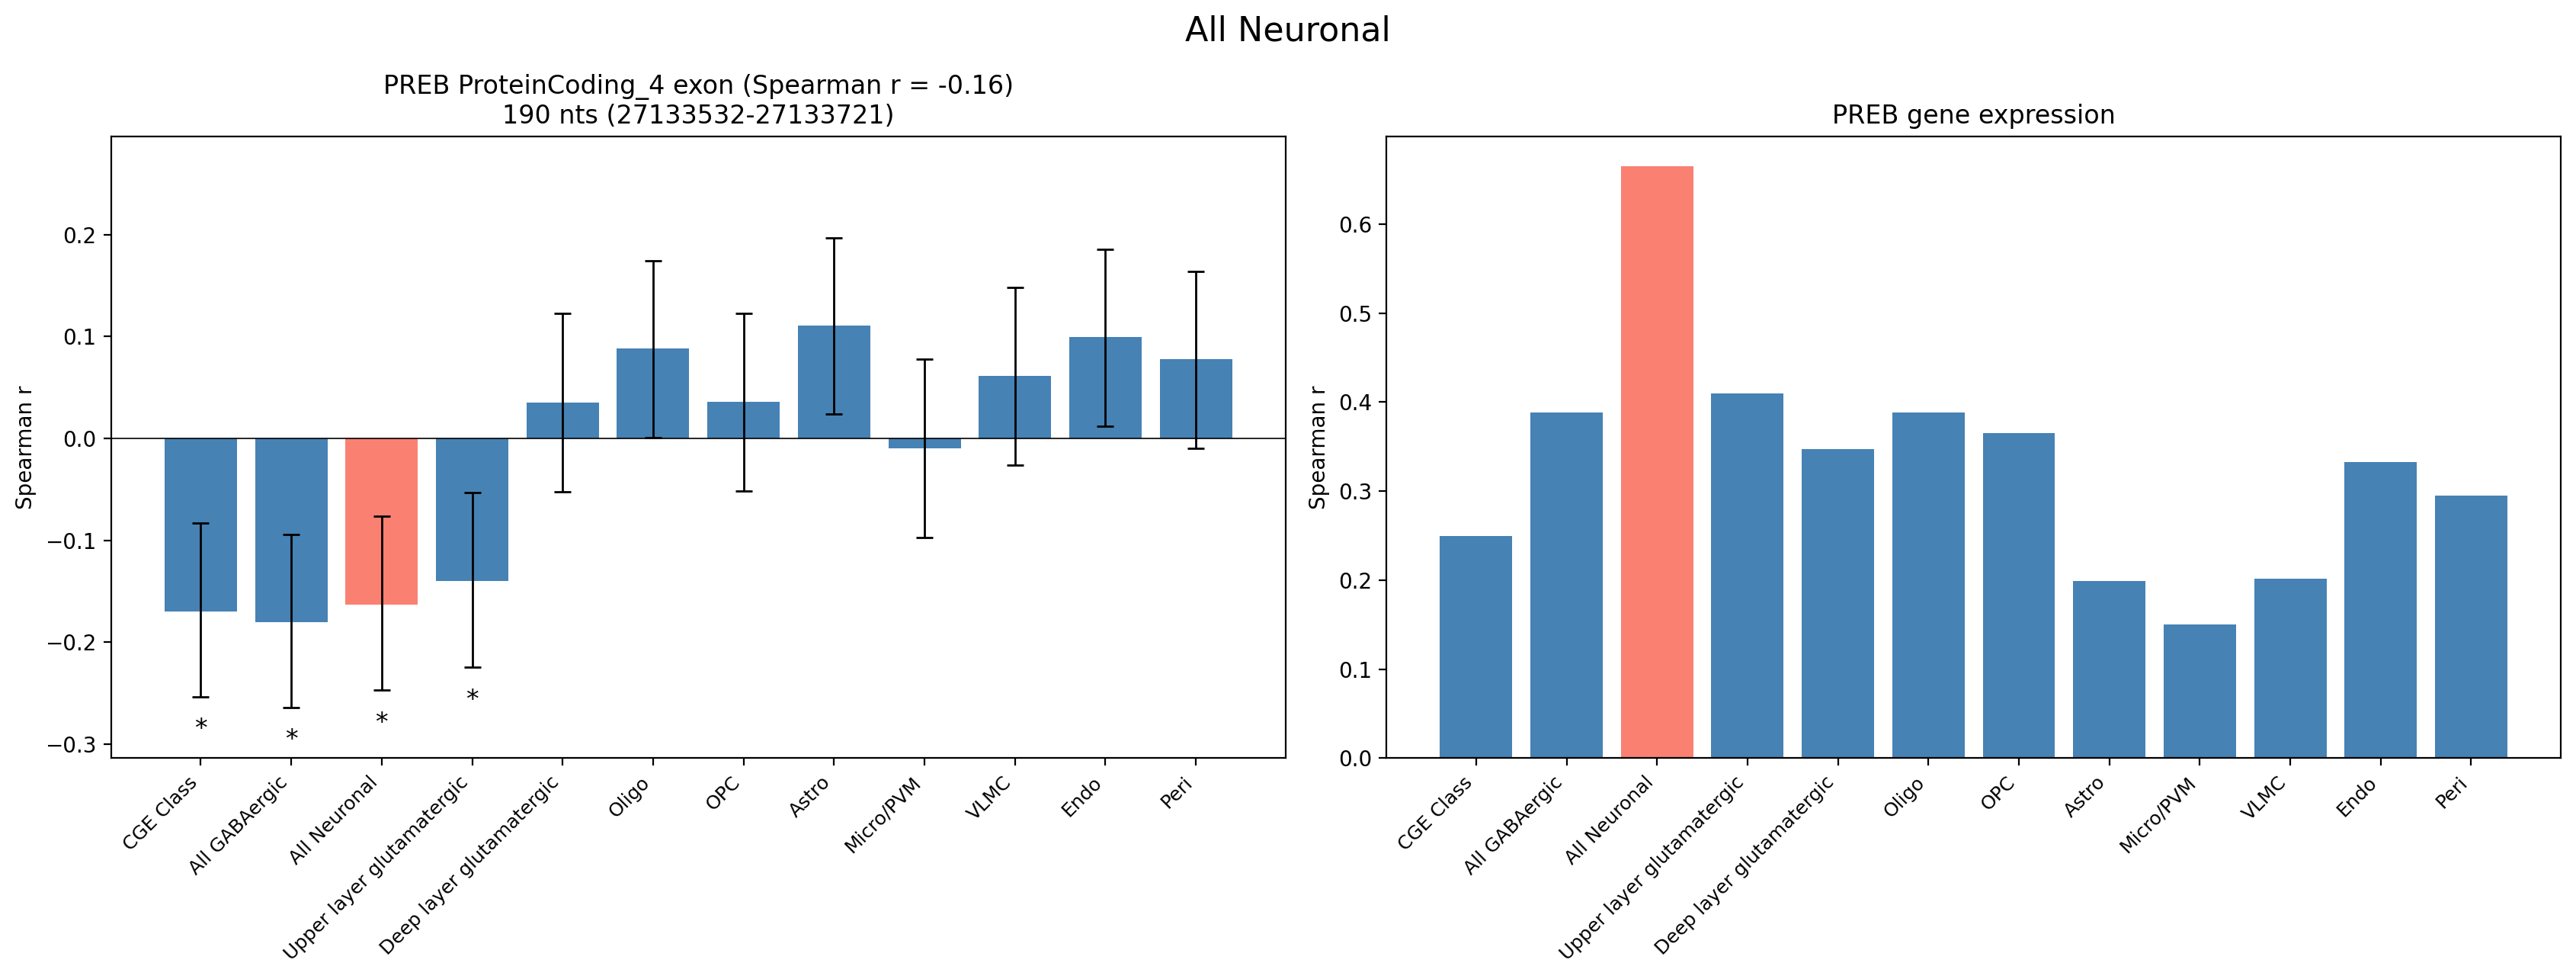

In [32]:
# --- plot strict specific exons (with bootstrap CIs) ---
outdir = "figures/ctype_exons"
for ascending in (True, False):
    plot_ctype_exons(
        ctype_specific_exons_strict[str(ascending)],
        psi_corr_df,
        psi_fdr_df.drop(columns='Gene'),
        expr_corr_df,
        exon_coords_df,
        psi_rank_centered,
        ct_ranks_dict,
        outdir=outdir,
        psi_ci_lower_df=psi_ci_lower_df,   # required if use_bootstrap_ci=False
        psi_ci_upper_df=psi_ci_upper_df,
        ascending=ascending,
        n_boot=None,
        use_bootstrap_ci=False
    )